In [ ]:
import os
import certifi
#import ssl

os.environ["SSL_CERT_FILE"] = certifi.where()
# ssl._create_default_https_context = ssl._create_unverified_context

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision.transforms import v2

import torch.nn as nn
import torch.functional as F

In [7]:
DATASET_PATH = os.path.expanduser('~/Downloads/neural_nets_data')

In [8]:
# Load and normalize the dataset MNIST

batch_size_training = 64
batch_size_testing = 1000

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    #v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #for datasets with 3 channels like CIFAR 
    v2.Normalize((0.1307,), (0.3081,))
])

trainset = torchvision.datasets.MNIST(root=DATASET_PATH, train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size_training, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root=DATASET_PATH, train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size_testing, shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.28789353..1.9107434].


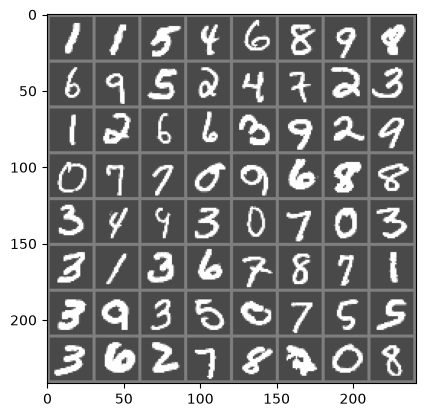

1     1     5     4     6     8     9     8     6     9     5     2     4     7     2     3     1     2     6     6     3     9     2     9     0     7     7     0     9     6     8     8     3     4     9     3     0     7     0     3     3     1     3     6     7     8     7     1     3     9     3     5     0     7     5     5     3     6     2     7     8     7     0     8    


In [15]:
# Visualize the loaded images
def imshow(img):
    img = img / 2 + 0.5 # unormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# getting some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[:64]))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size_training)))

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16, 5, 5)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()